# iQuHack 2026 - Quantum Entanglement Distillation Game

In this game, you design quantum circuits to distill noisy Bell pairs and claim edges in a network.

**Game Flow**: Register -> Select Starting Node -> Design Circuits -> Claim Edges -> Score Points

In [1]:
from client import GameClient
from visualization import GraphTool
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import json
from pathlib import Path

## Session Management

Save/load your session to avoid re-registering.

In [28]:
SESSION_FILE = Path("session.json")

def save_session(client):
    if client.api_token:
        with open(SESSION_FILE, "w") as f:
            json.dump({"api_token": client.api_token, "player_id": client.player_id, "name": client.name}, f)
        print(f"Session saved.")

def load_session():
    if not SESSION_FILE.exists():
        return None
    with open(SESSION_FILE) as f:
        data = json.load(f)
    client = GameClient(api_token=data.get("api_token"))
    client.player_id = data.get("player_id")
    client.name = data.get("name")
    status = client.get_status()
    if status:
        print(f"Resumed: {client.player_id} | Score: {status.get('score', 0)} | Budget: {status.get('budget', 0)}")
        return client
    return None

In [29]:
# Try to resume existing session
client = load_session()

if not client:
    print("No saved session. Register below.")

Resumed: Ram_23356 | Score: 16 | Budget: 81


## Step 1: Register

Skip this if you resumed a session above.

In [30]:
if client and client.api_token:
    print(f"Already registered as {client.player_id}")
else:
    client = GameClient()
    
    # CHANGE THESE to your unique values
    PLAYER_ID = "Ram_23356"
    PLAYER_NAME = "Ramachandran SS"
    
    result = client.register(PLAYER_ID, PLAYER_NAME, location=input("remote or in_person: ").strip())
    
    if result.get("ok"):
        print(f"Registered! Token: {client.api_token[:20]}...")
        candidates = result["data"].get("starting_candidates", [])
        print(f"\nStarting candidates ({len(candidates)}):")
        for c in candidates:
            print(f"  - {c['node_id']}: {c['utility_qubits']} qubits, +{c['bonus_bell_pairs']} bonus")
        save_session(client)
    else:
        print(f"Failed: {result.get('error', {}).get('message')}")

Already registered as Ram_23356


## Step 2: Select Starting Node

In [51]:
status = client.get_status()

if status.get('starting_node'):
    print(f"Starting node: {status['starting_node']}")
    print(f"Budget: {status['budget']} | Score: {status['score']}")
else:
    print("Select a starting node from the candidates shown above.")
    # Uncomment and modify:
    result = client.select_starting_node("Oslo, Norway")  # Kharagpur, India
    print(result)

Starting node: Oslo, Norway
Budget: 77 | Score: 21


In [90]:
# result = client.select_starting_node("Seoul, South Korea")  # Kharagpur, India
# print(result)

{'ok': True, 'data': {'success': True, 'starting_node': 'Seoul, South Korea', 'score': 24, 'budget': 72}}


## Step 3: Explore the Network

In [91]:
client.print_status()

Player: Ram_23356 (Ramachandran SS)
Score: 24 | Budget: 72 bell pairs
Active: Yes
Starting node: Seoul, South Korea
Owned: 10 nodes, 12 edges
Claimable edges: 19
  - ['Bergen, Norway', 'Oslo, Norway']: threshold=0.90, difficulty=2
  - ['Oslo, Norway', 'Uppsala, Sweden']: threshold=0.90, difficulty=3
  - ['Oslo, Norway', 'Trondheim, Norway']: threshold=0.90, difficulty=3
  ... and 16 more


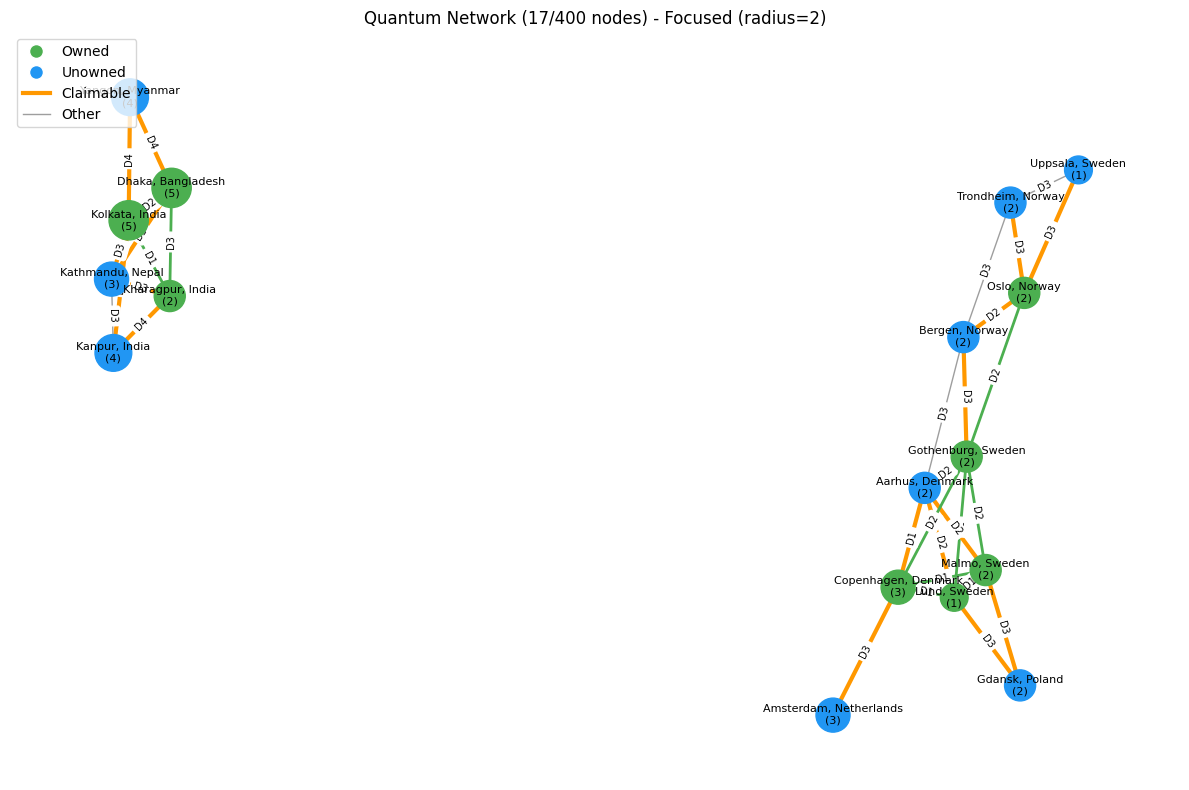

In [77]:
# Visualize the network (focused around your nodes)
viz = GraphTool(client.get_cached_graph())
owned = set(client.get_status().get('owned_nodes', []))
viz.render(owned)

## Step 4: Design a Distillation Circuit

For N Bell pairs, qubits are paired outside-in:
- Pair 0: qubits {0, 2N-1}
- Pair 1: qubits {1, 2N-2}
- ...
- Final pair: qubits {N-1, N}

Design a circuit that improves fidelity through LOCC operations.

In [46]:
from qiskit.circuit.classical import expr
import numpy as np
##### DEJMPS protocol
def create_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)
    qc.rx(np.pi/2, qr[0])
    qc.rx(np.pi/2, qr[1])

    qc.rx(-np.pi/2, qr[2])
    qc.rx(-np.pi/2, qr[3])
    
    qc.cx(qr[1],qr[0])
    qc.cx(qr[2],qr[3])

    qc.measure(qr[0],cr[0])
    qc.measure(qr[3],cr[1])

    qc.store(cr[2], expr.bit_xor(cr[0], cr[1]))
    
    return qc

circuit = create_distillation_circuit()
print(circuit.draw(output='text'))

     ┌─────────┐ ┌───┐┌─┐   
q_0: ┤ Rx(π/2) ├─┤ X ├┤M├───
     ├─────────┤ └─┬─┘└╥┘   
q_1: ┤ Rx(π/2) ├───■───╫────
     ├─────────┴┐      ║    
q_2: ┤ Rx(-π/2) ├──■───╫────
     ├──────────┤┌─┴─┐ ║ ┌─┐
q_3: ┤ Rx(-π/2) ├┤ X ├─╫─┤M├
     └──────────┘└───┘ ║ └╥┘
c: 3/══════════════════╩══╩═
                       0  1 


In [72]:
from qiskit.circuit.classical import expr
import numpy as np
#####  BBPSSW protocol - 2 Bell pairs
def create_distillation_circuit():
    """Example distillation circuit template for 2 Bell pairs."""
    qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
    cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
    qc = QuantumCircuit(qr, cr)
    
    # TODO: Add your distillation operations here
    # Qubit layout for N=2:
    #   q0, q3: Ancilla pair (to be measured)
    #   q1, q2: Data pair (output)
    qc.cx(qr[1],qr[0])
    qc.cx(qr[2],qr[3])

    qc.measure(qr[0],cr[0])
    qc.measure(qr[3],cr[1])

    qc.store(cr[2], expr.bit_xor(cr[0], cr[1]))
    
    return qc

circuit = create_distillation_circuit()
print(circuit.draw(output='text'))

     ┌───┐┌─┐   
q_0: ┤ X ├┤M├───
     └─┬─┘└╥┘   
q_1: ──■───╫────
           ║    
q_2: ──■───╫────
     ┌─┴─┐ ║ ┌─┐
q_3: ┤ X ├─╫─┤M├
     └───┘ ║ └╥┘
c: 3/══════╩══╩═
           0  1 


In [8]:
# from qiskit.circuit.classical import expr
# import numpy as np
# #####  BBPSSW protocol -  3 Bell pairs - FIND A 8 qubit node
# def create_distillation_circuit():
#     """Example distillation circuit template for 3 Bell pairs."""
#     qr = QuantumRegister(6, 'q')  # 6 qubits for 3 Bell pairs
#     cr = ClassicalRegister(5, 'c')  # Classical bits for measurements + flag
#     qc = QuantumCircuit(qr, cr)
    
#     # TODO: Add your distillation operations here
#     # Qubit layout for N=2:
#     #   q0, q3: Ancilla pair (to be measured)
#     #   q1, q2: Data pair (output)
#     qc.cx(qr[2],qr[0])
#     qc.cx(qr[2],qr[1])
    
#     qc.cx(qr[3],qr[5])
#     qc.cx(qr[3],qr[4])

#     qc.measure(qr[0],cr[0])
#     qc.measure(qr[1],cr[1])
#     qc.measure(qr[5],cr[2])
#     qc.measure(qr[4],cr[3])

#     qc.store(cr[4],expr.bit_xor(cr[0], cr[1]))
    
#     return qc

# circuit = create_distillation_circuit()
# print(circuit.draw(output='text'))

     ┌───┐     ┌─┐      
q_0: ┤ X ├─────┤M├──────
     └─┬─┘┌───┐└╥┘┌─┐   
q_1: ──┼──┤ X ├─╫─┤M├───
       │  └─┬─┘ ║ └╥┘   
q_2: ──■────■───╫──╫────
                ║  ║    
q_3: ──■────■───╫──╫────
       │  ┌─┴─┐ ║  ║ ┌─┐
q_4: ──┼──┤ X ├─╫──╫─┤M├
     ┌─┴─┐└┬─┬┘ ║  ║ └╥┘
q_5: ┤ X ├─┤M├──╫──╫──╫─
     └───┘ └╥┘  ║  ║  ║ 
c: 5/═══════╩═══╩══╩══╩═
            2   0  1  3 


In [11]:
# from qiskit.circuit.classical import expr
# import numpy as np
# #####  DEJMPS protocol -  3 Bell pairs - FIND A 8 qubit node
# def create_distillation_circuit():
#     """Example distillation circuit template for 3 Bell pairs."""
#     qr = QuantumRegister(6, 'q')  # 6 qubits for 3 Bell pairs
#     cr = ClassicalRegister(5, 'c')  # Classical bits for measurements + flag
#     qc = QuantumCircuit(qr, cr)
    
#     # TODO: Add your distillation operations here
#     # Qubit layout for N=2:
#     #   q0, q3: Ancilla pair (to be measured)
#     #   q1, q2: Data pair (output)
#     qc.rx(np.pi/2, qr[0])
#     qc.rx(np.pi/2, qr[1])
#     qc.rx(np.pi/2, qr[2])

#     qc.rx(-np.pi/2, qr[3])
#     qc.rx(-np.pi/2, qr[4])
#     qc.rx(-np.pi/2, qr[5])
    
#     qc.cx(qr[2],qr[0])
#     qc.cx(qr[2],qr[1])
    
#     qc.cx(qr[3],qr[5])
#     qc.cx(qr[3],qr[4])

#     qc.measure(qr[0],cr[0])
#     qc.measure(qr[1],cr[1])
#     qc.measure(qr[5],cr[2])
#     qc.measure(qr[4],cr[3])

#     qc.store(cr[4],expr.bit_xor(cr[0], cr[1]))
    
#     return qc

# circuit = create_distillation_circuit()
# print(circuit.draw(output='text'))

     ┌─────────┐ ┌───┐     ┌─┐      
q_0: ┤ Rx(π/2) ├─┤ X ├─────┤M├──────
     ├─────────┤ └─┬─┘┌───┐└╥┘┌─┐   
q_1: ┤ Rx(π/2) ├───┼──┤ X ├─╫─┤M├───
     ├─────────┤   │  └─┬─┘ ║ └╥┘   
q_2: ┤ Rx(π/2) ├───■────■───╫──╫────
     ├─────────┴┐           ║  ║    
q_3: ┤ Rx(-π/2) ├──■────■───╫──╫────
     ├──────────┤  │  ┌─┴─┐ ║  ║ ┌─┐
q_4: ┤ Rx(-π/2) ├──┼──┤ X ├─╫──╫─┤M├
     ├──────────┤┌─┴─┐└┬─┬┘ ║  ║ └╥┘
q_5: ┤ Rx(-π/2) ├┤ X ├─┤M├──╫──╫──╫─
     └──────────┘└───┘ └╥┘  ║  ║  ║ 
c: 5/═══════════════════╩═══╩══╩══╩═
                        2   0  1  3 


In [ ]:
# from qiskit.circuit.classical import expr
# import numpy as np
# #####  LOCNET protocol -  2 Bell pairs IN PROGRESS
# def create_distillation_circuit():
#     """Example distillation circuit template for 3 Bell pairs."""
#     qr = QuantumRegister(4, 'q')  # 4 qubits for 2 Bell pairs
#     cr = ClassicalRegister(3, 'c')  # Classical bits for measurements + flag
#     qc = QuantumCircuit(qr, cr)
    
#     # TODO: Add your distillation operations here
#     # Qubit layout for N=2:
#     #   q0, q3: Ancilla pair (to be measured)
#     #   q1, q2: Data pair (output)
#     qc.rx(np.pi/2, qr[0])
#     qc.rx(np.pi/2, qr[1])
#     qc.rx(np.pi/2, qr[2])

#     qc.rx(-np.pi/2, qr[3])
#     qc.rx(-np.pi/2, qr[4])
#     qc.rx(-np.pi/2, qr[5])
    
#     qc.cx(qr[2],qr[0])
#     qc.cx(qr[2],qr[1])
    
#     qc.cx(qr[3],qr[5])
#     qc.cx(qr[3],qr[4])

#     qc.measure(qr[0],cr[0])
#     qc.measure(qr[1],cr[1])
#     qc.measure(qr[5],cr[2])
#     qc.measure(qr[4],cr[3])

#     qc.store(cr[4],expr.bit_xor(cr[0], cr[1]))
    
#     return qc

# circuit = create_distillation_circuit()
# print(circuit.draw(output='text'))

## Step 5: Claim an Edge

In [92]:
# Find claimable edges
claimable = client.get_claimable_edges()
claimable_sorted = sorted(claimable, key=lambda e: (e['difficulty_rating'], e['base_threshold']))

print(f"Claimable edges ({len(claimable)}):")
for edge in claimable_sorted[:5]:
    print(f"  {edge['edge_id']} - threshold: {edge['base_threshold']:.3f}, difficulty: {edge['difficulty_rating']}")

Claimable edges (19):
  ['Daejeon, South Korea', 'Seoul, South Korea'] - threshold: 0.900, difficulty: 1
  ['Incheon, South Korea', 'Seoul, South Korea'] - threshold: 0.900, difficulty: 1
  ['Bergen, Norway', 'Oslo, Norway'] - threshold: 0.900, difficulty: 2
  ['Daegu, South Korea', 'Seoul, South Korea'] - threshold: 0.900, difficulty: 2
  ['Gwangju, South Korea', 'Seoul, South Korea'] - threshold: 0.900, difficulty: 2


In [74]:
# Claim an edge
if claimable:
    target = claimable_sorted[0]  # Easiest edge
    edge_id = tuple(target['edge_id'])
    
    circuit = create_distillation_circuit()
    num_bell_pairs = 2
    flag_bit = 2  # Classical bit for post-selection (keep when flag=0)
    
    print(f"Claiming {edge_id} (threshold: {target['base_threshold']:.3f})...")
    
    result = client.claim_edge(edge_id, circuit, flag_bit, num_bell_pairs)
    
    if result.get("ok"):
        data = result["data"]
        print(f"Success: {data.get('success')}")
        print(f"Fidelity: {data.get('fidelity', 0):.4f} (threshold: {data.get('threshold', 0):.4f})")
        print(f"Success probability: {data.get('success_probability', 0):.4f}")
    else:
        print(f"Error: {result.get('error', {}).get('message')}")

Claiming ('Aarhus, Denmark', 'Copenhagen, Denmark') (threshold: 0.900)...
Success: True
Fidelity: 0.9698 (threshold: 0.9000)
Success probability: 0.7450


## Step 6: Check Progress

In [75]:
client.print_status()

Player: Ram_23356 (Ramachandran SS)
Score: 24 | Budget: 71 bell pairs
Active: Yes
Starting node: Oslo, Norway
Owned: 8 nodes, 11 edges
Claimable edges: 18
  - ['Aarhus, Denmark', 'Copenhagen, Denmark']: threshold=0.90, difficulty=1
  - ['Bergen, Norway', 'Oslo, Norway']: threshold=0.90, difficulty=2
  - ['Oslo, Norway', 'Uppsala, Sweden']: threshold=0.90, difficulty=3
  ... and 15 more


In [25]:
# View leaderboard
leaderboard = client.get_leaderboard()["leaderboard"]
print("Leaderboard:")
for i, p in enumerate(leaderboard[:10]):
    print(f"{i+1}. {p.get('player_id', 'Unknown'):20} Score: {p.get('score', 0)}")

Leaderboard:
1. test_claude_1523b    Score: 446
2. riverst03            Score: 417
3. victor_prime         Score: 373
4. tumcuctom            Score: 363
5. ahkatlio_76f0869e    Score: 333
6. matcha_cat_42        Score: 332
7. A_PASTAR             Score: 307
8. prod_claude          Score: 306
9. evanli_nyu2          Score: 298
10. testetst12345        Score: 285


## Tips

- **Failed attempts are free** - only successful claims cost bell pairs
- **More bell pairs** can improve fidelity but cost more budget
- **Vertex rewards** are competitive - top players by claim strength earn rewards
- **Budget management** is key - if budget reaches 0, you're eliminated

Good luck!

In [16]:
# # # Restart game (uncomment to use)
# result = client.restart()
# print(result)

{'ok': True, 'data': {'success': True, 'budget': 75, 'is_active': True, 'starting_candidates': [{'node_id': 'Seoul, South Korea', 'utility_qubits': 5, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 37.5665, 'longitude': 126.978}, {'node_id': 'Kharagpur, India', 'utility_qubits': 2, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 22.346, 'longitude': 87.232}, {'node_id': 'Oslo, Norway', 'utility_qubits': 2, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 59.9139, 'longitude': 10.7522}, {'node_id': 'Zagreb, Croatia', 'utility_qubits': 3, 'bonus_bell_pairs': 1, 'capacity': 100, 'latitude': 45.815, 'longitude': 15.9819}]}}


In [81]:
graph = client.get_graph() 
edges = graph['edges']
print(edges[0:5])

[{'edge_id': ['College Park, MD', 'Washington, DC'], 'base_threshold': 0.9, 'difficulty_rating': 1, 'successful_attempts': 19}, {'edge_id': ['Baltimore, MD', 'College Park, MD'], 'base_threshold': 0.9, 'difficulty_rating': 1, 'successful_attempts': 28}, {'edge_id': ['College Park, MD', 'Richmond, VA'], 'base_threshold': 0.9, 'difficulty_rating': 2, 'successful_attempts': 4}, {'edge_id': ['Charlottesville, VA', 'College Park, MD'], 'base_threshold': 0.9, 'difficulty_rating': 2, 'successful_attempts': 6}, {'edge_id': ['Bothell, WA', 'Seattle, WA'], 'base_threshold': 0.9, 'difficulty_rating': 1, 'successful_attempts': 6}]


In [84]:
# Temp code Graph algorithm
import networkx as nx

G = nx.Graph()
start_nodes = ['Kharagpur, India','Oslo, Norway','Zagreb, Croatia','Seoul, South Korea']

for e in edges:
    n1, n2 = e["edge_id"]
    difficulty = e["difficulty_rating"]
    G.add_edge(n1, n2, weight=difficulty)

In [89]:
import heapq

def dijkstra_reachable_nodes(G, start):
    """
    Return all nodes reachable from `start` using only edges
    with difficulty 1 or 2.
    """
    allowed = {1, 2}
    visited = set()
    pq = [(0, start)]  # (cost, node)

    while pq:
        cost, node = heapq.heappop(pq)
        print(node)
        if node in visited:
            continue
        visited.add(node)

        for neighbor in G.neighbors(node):
            diff = G[node][neighbor]["weight"]
            if diff in allowed and neighbor not in visited:
                heapq.heappush(pq, (diff, neighbor))

    return visited

dijkstra_reachable_nodes(G,start_nodes[2])

Zagreb, Croatia
Graz, Austria
Ljubljana, Slovenia
Ljubljana, Slovenia
Vienna, Austria
Bratislava, Slovakia
Brno, Czechia
Brno, Czechia
Linz, Austria
Salzburg, Austria
Innsbruck, Austria
Munich, Germany
Munich, Germany
Nuremberg, Germany
Stuttgart, Germany
Frankfurt, Germany
Bonn, Germany
Aachen, Germany
Cologne, Germany
Cologne, Germany
Cologne, Germany
Dortmund, Germany
Dortmund, Germany
Dusseldorf, Germany
Dusseldorf, Germany
Dusseldorf, Germany
Dusseldorf, Germany
Eindhoven, Netherlands
Antwerp, Belgium
Brussels, Belgium
Essen, Germany
Essen, Germany
Essen, Germany
Essen, Germany
Ghent, Belgium
Ghent, Belgium
Heidelberg, Germany
Heidelberg, Germany
Leuven, Belgium
Leuven, Belgium
Leuven, Belgium
Leuven, Belgium
Lille, France
Lille, France
Lille, France
Lille, France
Luxembourg City
Luxembourg City
Luxembourg City
Strasbourg, France
Basel, Switzerland
Bern, Switzerland
Geneva, Switzerland
Grenoble, France
Lausanne, Switzerland
Lausanne, Switzerland
Lausanne, Switzerland
Lyon, France


{'Aachen, Germany',
 'Amsterdam, Netherlands',
 'Antwerp, Belgium',
 'Barcelona, Spain',
 'Basel, Switzerland',
 'Belfast, UK',
 'Berlin, Germany',
 'Bern, Switzerland',
 'Bilbao, Spain',
 'Birmingham, UK',
 'Bologna, Italy',
 'Bonn, Germany',
 'Bordeaux, France',
 'Bratislava, Slovakia',
 'Bremen, Germany',
 'Bristol, UK',
 'Brno, Czechia',
 'Brussels, Belgium',
 'Budapest, Hungary',
 'Cambridge, UK',
 'Cardiff, UK',
 'Cologne, Germany',
 'Cork, Ireland',
 'Delft, Netherlands',
 'Dortmund, Germany',
 'Dresden, Germany',
 'Dublin, Ireland',
 'Dusseldorf, Germany',
 'Edinburgh, UK',
 'Eindhoven, Netherlands',
 'Essen, Germany',
 'Florence, Italy',
 'Frankfurt, Germany',
 'Galway, Ireland',
 'Gdansk, Poland',
 'Geneva, Switzerland',
 'Ghent, Belgium',
 'Glasgow, UK',
 'Graz, Austria',
 'Grenoble, France',
 'Groningen, Netherlands',
 'Hamburg, Germany',
 'Hanover, Germany',
 'Heidelberg, Germany',
 'Innsbruck, Austria',
 'Krakow, Poland',
 'Lausanne, Switzerland',
 'Leeds, UK',
 'Leiden, 